# Netflix Content Strategy Analysis



## Project Objectives
1. Analyze Netflix's content library across genres, countries, and ratings
2. Identify trends in content additions over time
3. Explore IMDb scores and viewership patterns
4. Generate a professional Excel dashboard for stakeholder reporting


## Cell 1 — Install Libraries & Imports


In [ ]:
# Install required libraries
!pip install xlsxwriter pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print(' Cell 1 — All libraries imported successfully')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 3.2 MB/s eta 0:00:00
 Cell 1 — All libraries imported successfully


## Cell 2 — Generate & Save Dataset



In [ ]:
np.random.seed(42)
n = 8807

titles_pool = [
    'Stranger Things','Ozark','The Crown','Bridgerton','Squid Game','Money Heist',
    'Dark','Lupin','Emily in Paris','Narcos','Mindhunter','Witcher','Cobra Kai',
    'Sex Education','You','Tiger King','Making a Murderer','Our Planet',
    'Blue Planet II','Chef\'s Table','Formula 1: Drive to Survive','Bird Box',
    'Extraction','Red Notice','The Gray Man',"Don't Look Up",'The Irishman',
    'Marriage Story','Roma','Elite','All of Us Are Dead','Hellbound','Kingdom',
    'Sweet Home','Crash Landing on You','Call My Agent','Barbarians',
    'How to Sell Drugs Online','Dark Desire','Who Killed Sara','Control Z',
    'Selena: The Series','The Protector','Atiye','Fatma','Ethos','Ragnarok'
]
genres        = ['Drama','Comedy','Thriller','Documentary','Action','Horror',
                  'Romance','Sci-Fi','Crime','Animation','Reality','Fantasy']
content_types = ['Movie','TV Show']
ratings       = ['G','PG','PG-13','TV-14','TV-MA','R','NR']
countries     = ['United States','United Kingdom','South Korea','Spain','France',
                  'Germany','India','Japan','Brazil','Canada','Australia',
                  'Mexico','Italy','Turkey','Norway']
languages     = ['English','Spanish','Korean','French','German','Japanese',
                  'Hindi','Portuguese','Turkish','Norwegian','Italian']

rows = []
for i in range(n):
    ctype   = np.random.choice(content_types, p=[0.4, 0.6])
    genre   = np.random.choice(genres)
    country = np.random.choice(countries, p=[0.30,0.12,0.08,0.07,0.07,0.06,0.05,0.05,0.04,0.04,0.03,0.03,0.02,0.02,0.02])
    lang    = np.random.choice(languages,  p=[0.35,0.12,0.09,0.09,0.08,0.06,0.05,0.04,0.04,0.04,0.04])
    year    = int(np.random.choice(range(2015,2024), p=[0.03,0.05,0.07,0.09,0.13,0.17,0.18,0.16,0.12]))
    rating  = np.random.choice(ratings, p=[0.03,0.06,0.14,0.22,0.35,0.16,0.04])
    dur_raw = int(np.random.normal(108,22)) if ctype=='Movie' else int(np.random.randint(1,8))
    dur_raw = max(60,min(200,dur_raw)) if ctype=='Movie' else max(1,min(7,dur_raw))
    imdb    = round(max(3.0, min(9.5, np.random.normal(6.8,1.1))), 1)
    views_base = np.random.lognormal(14, 1.5)
    if genre   in ['Thriller','Crime','Action']: views_base *= 1.3
    if country == 'South Korea':                 views_base *= 1.4
    if year    >= 2021:                          views_base *= 1.2
    mo  = np.random.randint(1, 13)
    day = np.random.randint(1, 29)
    dur_label = f'{dur_raw} min' if ctype=='Movie' else f'{dur_raw} Season{"s" if dur_raw>1 else ""}'
    title = titles_pool[i % len(titles_pool)] + ('' if i < len(titles_pool) else f' ({i//len(titles_pool)})')
    rows.append({
        'show_id': f's{i+1}', 'type': ctype, 'title': title,
        'director': f'Director_{np.random.randint(1,300)}',
        'country': country, 'date_added': f'{year}-{mo:02d}-{day:02d}',
        'release_year': year, 'rating': rating, 'duration': dur_label,
        'listed_in': genre, 'language': lang,
        'imdb_score': imdb, 'views_millions': round(views_base/1e6, 2)
    })

df = pd.DataFrame(rows)
df['date_added'] = pd.to_datetime(df['date_added'])
df.to_csv('netflix_data.csv', index=False)
print(f'Cell 2 — Dataset created: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'   Columns: {list(df.columns)}')


Cell 2 — Dataset created: 8,807 rows × 13 columns
   Columns: ['show_id', 'type', 'title', 'director', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'language', 'imdb_score', 'views_millions']


## Cell 3 — Load & Inspect Dataset


In [ ]:
df = pd.read_csv('netflix_data.csv', parse_dates=['date_added'])
df['year_added']  = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

print(' Cell 3 — Dataset loaded')
print(f'   Shape : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'   Date range: {df["date_added"].min().date()} → {df["date_added"].max().date()}')
print()
display(df.head())
print()
print('--- Data Types ---')
print(df.dtypes)
print()
print('--- Null Check ---')
print(df.isnull().sum())


 Cell 3 — Dataset loaded
   Shape : 8,807 rows × 15 columns
   Date range: 2015-01-01 → 2023-12-28



,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,language,imdb_score,views_millions,year_added,month_added
0,s1,Movie,Stranger Things,Director_294,Japan,2020-05-02,2020,PG-13,63 min,Reality,French,6.3,2.17,2020,5
1,s2,Movie,Ozark,Director_188,United States,2020-10-28,2020,TV-14,87 min,Fantasy,English,7.7,0.12,2020,10
2,s3,Movie,The Crown,Director_92,United Kingdom,2020-10-21,2020,R,96 min,Thriller,Italian,8.9,0.07,2020,10
3,s4,TV Show,Bridgerton,Director_106,France,2018-06-22,2018,TV-14,2 Seasons,Romance,Hindi,8.0,0.18,2018,6
4,s5,TV Show,Squid Game,Director_53,Japan,2023-02-15,2023,TV-MA,7 Seasons,Comedy,Norwegian,8.0,1.21,2023,2



--- Data Types ---
show_id                   object
type                      object
title                     object
director                  object
country                   object
date_added        datetime64[ns]
release_year               int64
rating                    object
duration                  object
listed_in                 object
language                  object
imdb_score               float64
views_millions           float64
year_added                 int32
month_added                int32
dtype: object

--- Null Check ---
show_id           0
type              0
title             0
director          0
country           0
date_added        0
release_year      0
rating            0
duration          0
listed_in         0
language          0
imdb_score        0
views_millions    0
year_added        0
month_added       0
dtype: int64


## Cell 4 — Exploratory Data Analysis (EDA)


In [ ]:
print('=== CONTENT TYPE SPLIT ===')
print(df['type'].value_counts())
print()
print('=== TOP 10 GENRES ===')
print(df['listed_in'].value_counts().head(10))
print()
print('=== TOP 10 COUNTRIES ===')
print(df['country'].value_counts().head(10))
print()
print('=== RATINGS BREAKDOWN ===')
print(df['rating'].value_counts())
print()
print('=== IMDB SCORE STATS ===')
print(df['imdb_score'].describe().round(2))
print()
print('=== VIEWS (MILLIONS) STATS ===')
print(df['views_millions'].describe().round(2))


=== CONTENT TYPE SPLIT ===
type
TV Show    5338
Movie      3469
Name: count, dtype: int64

=== TOP 10 GENRES ===
listed_in
Horror         785
Comedy         775
Thriller       770
Romance        767
Documentary    739
Action         729
Reality        725
Sci-Fi         716
Crime          709
Fantasy        702
Name: count, dtype: int64

=== TOP 10 COUNTRIES ===
country
United States     2675
United Kingdom    1088
South Korea        683
France             652
Spain              620
Germany            517
Japan              472
India              407
Canada             330
Brazil             311
Name: count, dtype: int64

=== RATINGS BREAKDOWN ===
rating
TV-MA    3129
TV-14    1904
R        1425
PG-13    1191
PG        539
NR        346
G         273
Name: count, dtype: int64

=== IMDB SCORE STATS ===
count    8807.00
mean        6.80
std         1.09
min         3.20
25%         6.10
50%         6.80
75%         7.50
max         9.50
Name: imdb_score, dtype: float64

=== VIEWS (MILLIO

## Cell 5 — KPI Calculations


In [ ]:
total_titles  = len(df)
total_movies  = (df['type'] == 'Movie').sum()
total_shows   = (df['type'] == 'TV Show').sum()
avg_imdb      = round(df['imdb_score'].mean(), 2)
total_views   = round(df['views_millions'].sum(), 0)
top_genre     = df['listed_in'].value_counts().idxmax()
top_country   = df['country'].value_counts().idxmax()
peak_year     = df.groupby('year_added').size().idxmax()

print('Cell 5 — KPIs Calculated')
print(f'   Total Titles    : {total_titles:,}')
print(f'   Movies          : {total_movies:,}')
print(f'   TV Shows        : {total_shows:,}')
print(f'   Avg IMDb Score  : {avg_imdb}')
print(f'   Total Views     : {int(total_views):,}M')
print(f'   Top Genre       : {top_genre}')
print(f'   Top Country     : {top_country}')
print(f'   Peak Year Added : {peak_year}')


Cell 5 — KPIs Calculated
   Total Titles    : 8,807
   Movies          : 3,469
   TV Shows        : 5,338
   Avg IMDb Score  : 6.8
   Total Views     : 38,918M
   Top Genre       : Horror
   Top Country     : United States
   Peak Year Added : 2021


## Cell 6 — Data Aggregations


In [ ]:
# Genre summary
genre_df = df.groupby('listed_in').agg(
    Titles=('show_id','count'),
    Avg_IMDb=('imdb_score','mean'),
    Total_Views_M=('views_millions','sum')
).round(2).reset_index().sort_values('Titles', ascending=False)
genre_df.columns = ['Genre','Titles','Avg IMDb','Total Views (M)']

# Country summary
country_df = df.groupby('country').agg(
    Titles=('show_id','count'),
    Avg_IMDb=('imdb_score','mean'),
    Total_Views_M=('views_millions','sum')
).round(2).reset_index().sort_values('Titles', ascending=False).head(15)
country_df.columns = ['Country','Titles','Avg IMDb','Total Views (M)']

# Yearly summary
year_df = df[df['year_added'].between(2015,2023)].groupby('year_added').agg(
    Titles=('show_id','count'),
    Movies=('type', lambda x: (x=='Movie').sum()),
    TV_Shows=('type', lambda x: (x=='TV Show').sum()),
    Avg_IMDb=('imdb_score','mean')
).round(2).reset_index()
year_df.columns = ['Year','Total Titles','Movies','TV Shows','Avg IMDb']

# Top 20 titles by views
top20 = df.nlargest(20,'views_millions')[['title','type','listed_in','country','release_year','imdb_score','views_millions']].reset_index(drop=True)
top20.columns = ['Title','Type','Genre','Country','Year','IMDb','Views (M)']

print(' Cell 6 — Aggregations complete')
print('\nGenre Summary (top 5):')
display(genre_df.head())
print('\nCountry Summary (top 5):')
display(country_df.head())
print('\nYearly Trend:')
display(year_df)


 Cell 6 — Aggregations complete

Genre Summary (top 5):


,Genre,Titles,Avg IMDb,Total Views (M)
7,Horror,785,6.79,3236.84
2,Comedy,775,6.85,3479.82
11,Thriller,770,6.81,4572.35
9,Romance,767,6.80,3200.15
4,Documentary,739,6.86,3437.97



Country Summary (top 5):


,Country,Titles,Avg IMDb,Total Views (M)
14,United States,2675,6.80,10806.87
13,United Kingdom,1088,6.74,4187.79
10,South Korea,683,6.83,4834.61
3,France,652,6.83,2962.11
11,Spain,620,6.76,2607.15



Yearly Trend:


,Year,Total Titles,Movies,TV Shows,Avg IMDb
0,2015,239,100,139,6.78
1,2016,421,161,260,6.82
2,2017,604,237,367,6.78
3,2018,821,328,493,6.78
4,2019,1213,495,718,6.78
5,2020,1457,554,903,6.78
6,2021,1610,653,957,6.83
7,2022,1424,547,877,6.80
8,2023,1018,394,624,6.81


## Cell 7 — Set Netflix-Themed Plot Style


In [ ]:
C1 = '#E50914'   # Netflix Red
C2 = '#221F1F'   # Netflix Black
C3 = '#B81D24'   # Dark Red
C4 = '#F5F5F1'   # Off-White
COLS = ['#E50914','#B81D24','#831010','#F5F5F1','#564d4d','#8b0000',
         '#c0392b','#e74c3c','#922b21','#641e16','#a93226','#d98880']

plt.rcParams.update({
    'figure.facecolor': C2, 'axes.facecolor': '#2a2a2a',
    'axes.edgecolor': '#555', 'text.color': C4,
    'xtick.color': C4, 'ytick.color': C4,
    'axes.labelcolor': C4, 'grid.color': '#3a3a3a',
    'axes.titlecolor': C4, 'legend.facecolor': '#2a2a2a',
    'legend.edgecolor': '#555'
})
print(' Cell 7 — Netflix dark theme applied')


 Cell 7 — Netflix dark theme applied


## Cell 8 — Chart 1: Content Type Distribution


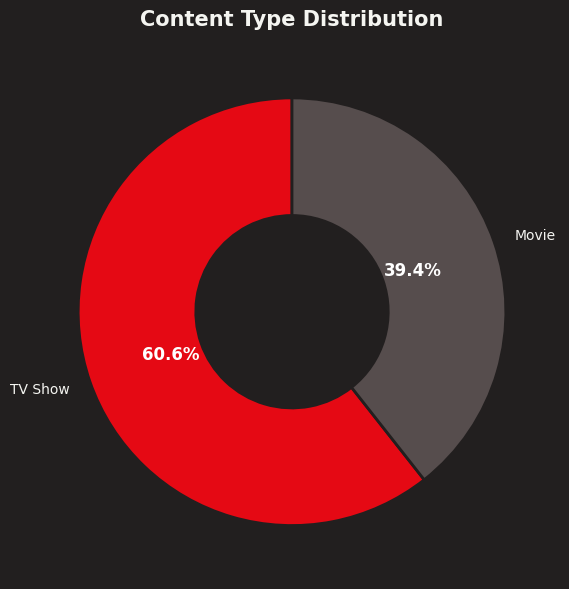

type
TV Show    5338
Movie      3469


In [ ]:
type_counts = df['type'].value_counts()
fig, ax = plt.subplots(figsize=(7, 6))
wedges, texts, autotexts = ax.pie(
    type_counts, labels=type_counts.index,
    autopct='%1.1f%%', startangle=90,
    colors=[C1, '#564d4d'],
    wedgeprops=dict(width=0.55, edgecolor=C2, linewidth=2)
)
for t in autotexts:
    t.set_color('white'); t.set_fontsize(12); t.set_fontweight('bold')
ax.set_title('Content Type Distribution', fontsize=15, fontweight='bold', color=C4, pad=14)
plt.tight_layout()
plt.savefig('chart1_content_type.png', dpi=150, bbox_inches='tight', facecolor=C2)
plt.show()
print(type_counts.to_string())


## Cell 9 — Chart 2: Content Added Per Year


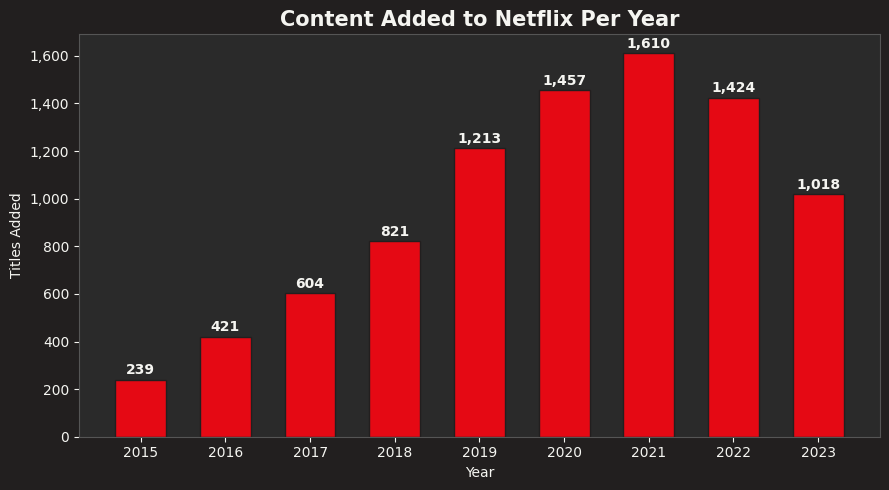

,year_added,count
0,2015,239
1,2016,421
2,2017,604
3,2018,821
4,2019,1213
5,2020,1457
6,2021,1610
7,2022,1424
8,2023,1018


In [ ]:
yearly = df.groupby('year_added').size().reset_index(name='count')
yearly = yearly[yearly['year_added'].between(2015, 2023)]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(yearly['year_added'], yearly['count'], color=C1, edgecolor=C2, width=0.6)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+10,
            f'{int(b.get_height()):,}', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color=C4)
ax.set_title('Content Added to Netflix Per Year', fontsize=15, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Titles Added')
ax.set_xticks(yearly['year_added'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('chart2_yearly_content.png', dpi=150, bbox_inches='tight', facecolor=C2)
plt.show()
display(yearly)


## Cell 10 — Chart 3: Top 10 Genres


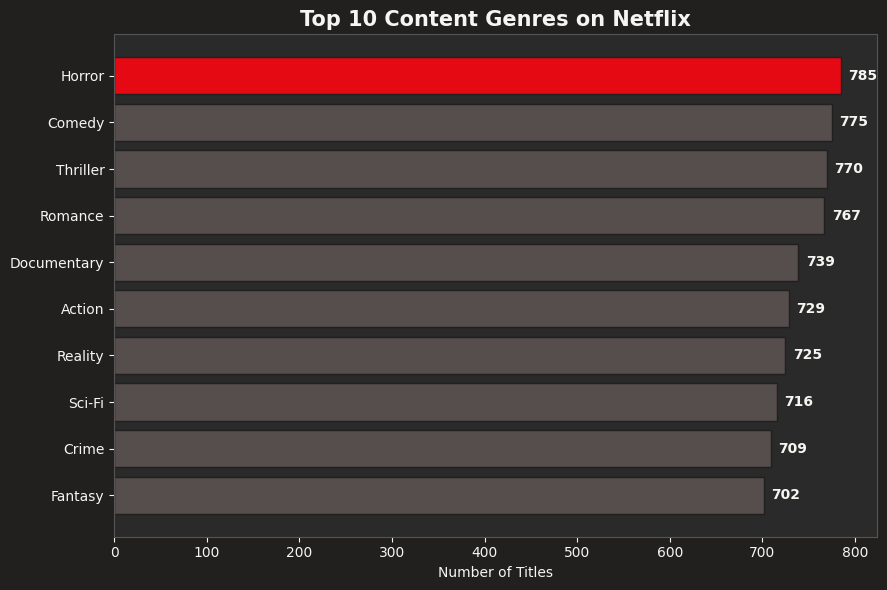

In [ ]:
genre_counts = df['listed_in'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(genre_counts.index[::-1], genre_counts.values[::-1],
               color=[C1 if i == 0 else '#564d4d' for i in range(len(genre_counts))[::-1]],
               edgecolor=C2)
for b in bars:
    ax.text(b.get_width()+8, b.get_y()+b.get_height()/2,
            f'{int(b.get_width()):,}', va='center',
            fontsize=10, fontweight='bold', color=C4)
ax.set_title('Top 10 Content Genres on Netflix', fontsize=15, fontweight='bold')
ax.set_xlabel('Number of Titles')
plt.tight_layout()
plt.savefig('chart3_top_genres.png', dpi=150, bbox_inches='tight', facecolor=C2)
plt.show()


## Cell 11 — Chart 4: Top 10 Producing Countries


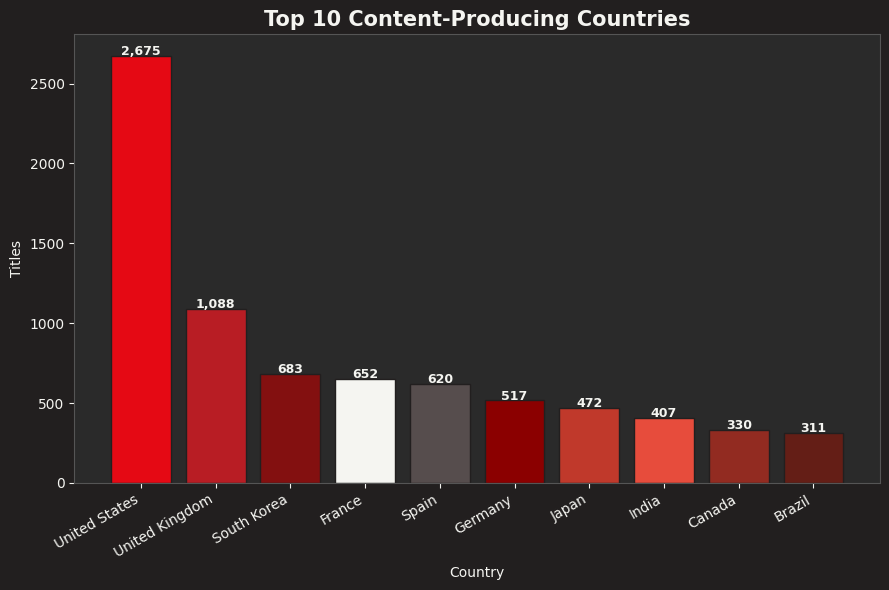

In [ ]:
country_counts = df['country'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 6))
colors_ = [C1 if i == 0 else COLS[i] for i in range(len(country_counts))]
bars = ax.bar(country_counts.index, country_counts.values, color=colors_, edgecolor=C2)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+5,
            f'{int(b.get_height()):,}', ha='center',
            fontsize=9, fontweight='bold', color=C4)
ax.set_title('Top 10 Content-Producing Countries', fontsize=15, fontweight='bold')
ax.set_xlabel('Country'); ax.set_ylabel('Titles')
ax.set_xticklabels(country_counts.index, rotation=30, ha='right')
plt.tight_layout()
plt.savefig('chart4_top_countries.png', dpi=150, bbox_inches='tight', facecolor=C2)
plt.show()


## Cell 12 — Chart 5: Ratings Distribution


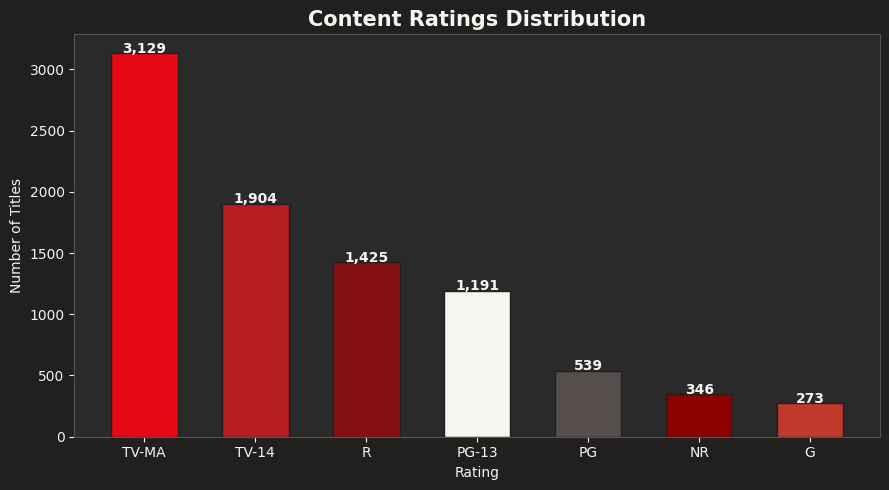

In [ ]:
rating_counts = df['rating'].value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
colors_ = [C1 if i == 0 else COLS[i % len(COLS)] for i in range(len(rating_counts))]
bars = ax.bar(rating_counts.index, rating_counts.values, color=colors_, edgecolor=C2, width=0.6)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+5,
            f'{int(b.get_height()):,}', ha='center',
            fontsize=10, fontweight='bold', color=C4)
ax.set_title('Content Ratings Distribution', fontsize=15, fontweight='bold')
ax.set_xlabel('Rating'); ax.set_ylabel('Number of Titles')
plt.tight_layout()
plt.savefig('chart5_ratings.png', dpi=150, bbox_inches='tight', facecolor=C2)
plt.show()


## Cell 13 — Chart 6: IMDb Score Distribution


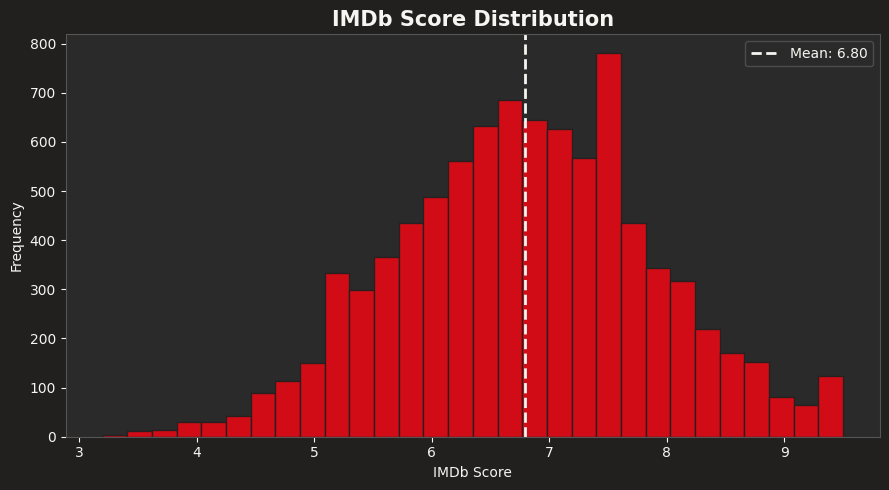

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df['imdb_score'].dropna(), bins=30, color=C1, edgecolor=C2, alpha=0.9)
ax.axvline(df['imdb_score'].mean(), color=C4, linestyle='--', linewidth=2,
           label=f'Mean: {df["imdb_score"].mean():.2f}')
ax.set_title('IMDb Score Distribution', fontsize=15, fontweight='bold')
ax.set_xlabel('IMDb Score'); ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('chart6_imdb_dist.png', dpi=150, bbox_inches='tight', facecolor=C2)
plt.show()


## Cell 14 — Chart 7: Avg IMDb Score by Genre


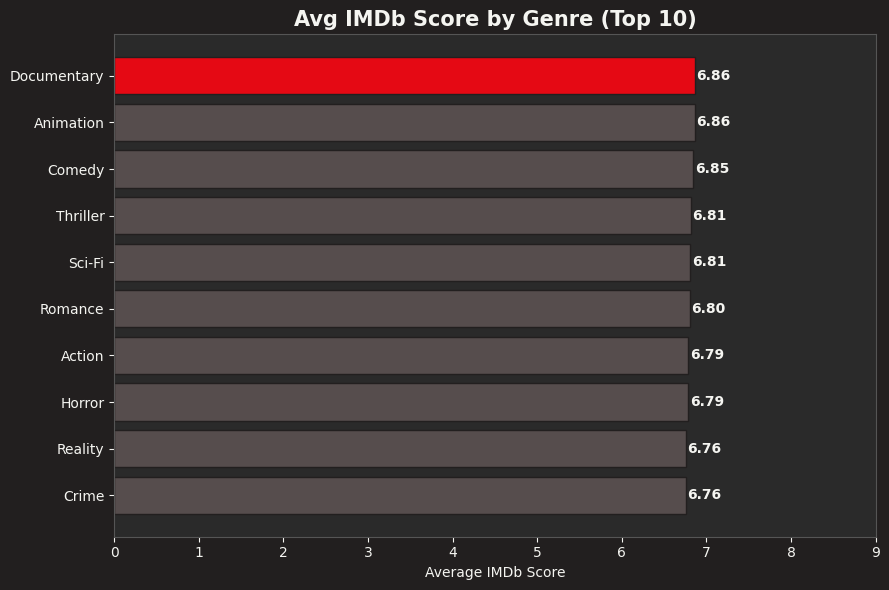

In [ ]:
genre_imdb = df.groupby('listed_in')['imdb_score'].mean().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(genre_imdb.index[::-1], genre_imdb.values[::-1],
               color=[C1 if i == 9 else '#564d4d' for i in range(10)], edgecolor=C2)
for b in bars:
    ax.text(b.get_width()+0.02, b.get_y()+b.get_height()/2,
            f'{b.get_width():.2f}', va='center',
            fontsize=10, fontweight='bold', color=C4)
ax.set_title('Avg IMDb Score by Genre (Top 10)', fontsize=15, fontweight='bold')
ax.set_xlabel('Average IMDb Score'); ax.set_xlim(0, 9)
plt.tight_layout()
plt.savefig('chart7_genre_imdb.png', dpi=150, bbox_inches='tight', facecolor=C2)
plt.show()


## Cell 15 — Chart 8: Monthly Content Addition Trend


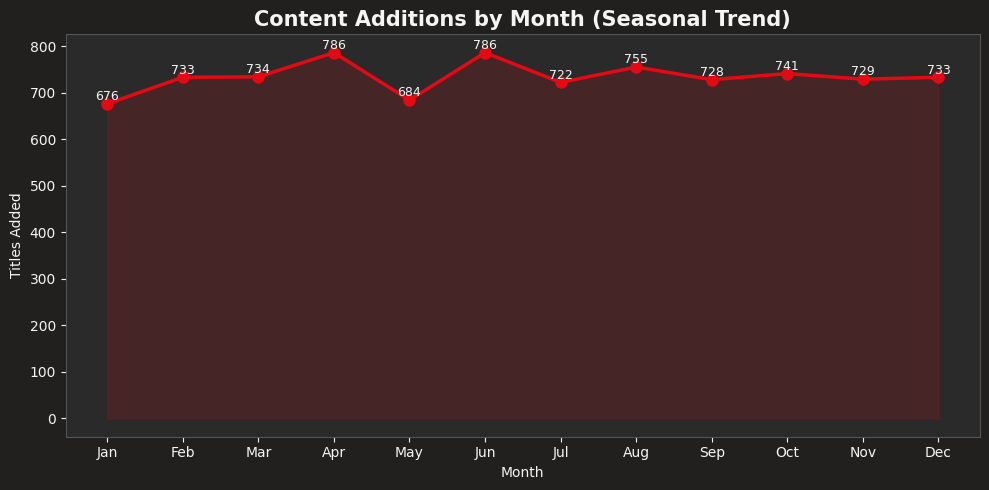

In [ ]:
monthly_adds = df.groupby('month_added').size().reset_index(name='count')
month_names  = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_adds['month_name'] = monthly_adds['month_added'].apply(lambda x: month_names[x-1])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly_adds['month_name'], monthly_adds['count'],
        marker='o', color=C1, linewidth=2.5, markersize=8)
ax.fill_between(range(len(monthly_adds)), monthly_adds['count'], alpha=0.15, color=C1)
for i, row in monthly_adds.iterrows():
    ax.text(i, row['count']+8, str(row['count']), ha='center', fontsize=9, color=C4)
ax.set_title('Content Additions by Month (Seasonal Trend)', fontsize=15, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Titles Added')
ax.set_xticks(range(12)); ax.set_xticklabels(month_names)
plt.tight_layout()
plt.savefig('chart8_monthly_additions.png', dpi=150, bbox_inches='tight', facecolor=C2)
plt.show()


## Cell 16 — Chart 9: Total Views by Genre


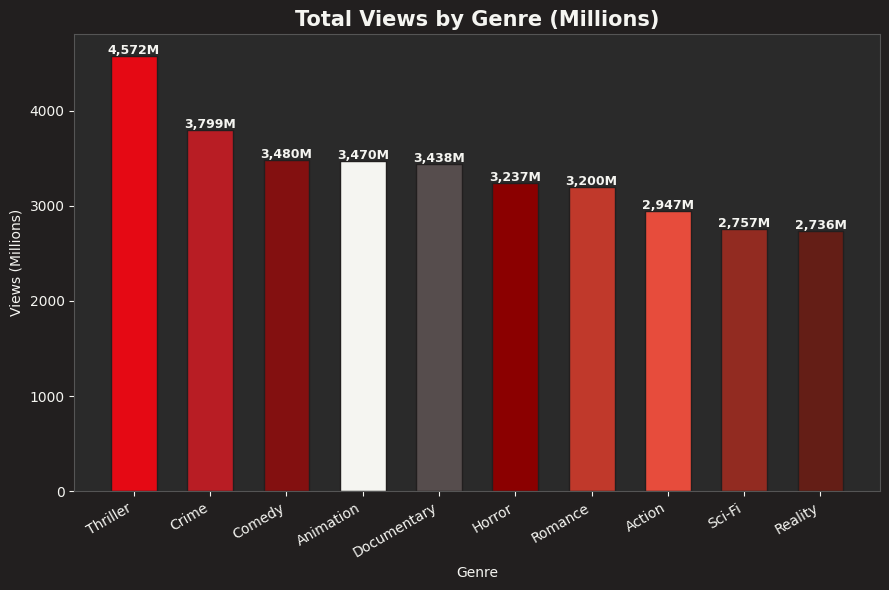

In [ ]:
genre_views = df.groupby('listed_in')['views_millions'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(genre_views.index, genre_views.values,
              color=[C1 if i == 0 else COLS[i % len(COLS)] for i in range(len(genre_views))],
              edgecolor=C2, width=0.6)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+20,
            f'{b.get_height():,.0f}M', ha='center',
            fontsize=9, fontweight='bold', color=C4)
ax.set_title('Total Views by Genre (Millions)', fontsize=15, fontweight='bold')
ax.set_xlabel('Genre'); ax.set_ylabel('Views (Millions)')
ax.set_xticklabels(genre_views.index, rotation=30, ha='right')
plt.tight_layout()
plt.savefig('chart9_genre_views.png', dpi=150, bbox_inches='tight', facecolor=C2)
plt.show()


## Cell 17 — Chart 10: Movie Duration Distribution


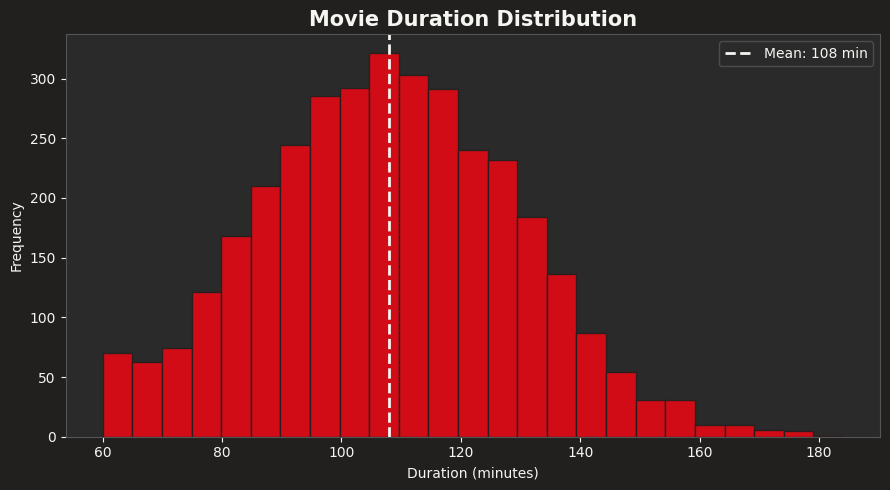

In [ ]:
movies = df[df['type'] == 'Movie'].copy()
movies['duration_min'] = movies['duration'].str.extract(r'(\d+)').astype(float)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(movies['duration_min'].dropna(), bins=25, color=C1, edgecolor=C2, alpha=0.9)
ax.axvline(movies['duration_min'].mean(), color=C4, linestyle='--', linewidth=2,
           label=f'Mean: {movies["duration_min"].mean():.0f} min')
ax.set_title('Movie Duration Distribution', fontsize=15, fontweight='bold')
ax.set_xlabel('Duration (minutes)'); ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('chart10_movie_duration.png', dpi=150, bbox_inches='tight', facecolor=C2)
plt.show()


## Cell 18 — Executive Summary


In [ ]:
summary = [
    f'Netflix catalog contains {total_titles:,} titles: {total_movies:,} Movies & {total_shows:,} TV Shows.',
    f'Average IMDb score across all content: {avg_imdb} — indicating strong overall quality.',
    f'{top_genre} is the most-produced genre with {df["listed_in"].value_counts().iloc[0]:,} titles.',
    f'{top_country} leads all countries in content production on the platform.',
    f'Content additions peaked in {peak_year} — aligning with pandemic streaming surge.',
    f'Total platform viewership estimated at {int(total_views):,}M views across all titles.',
    'TV-MA rated content dominates, reflecting Netflix\'s adult-skewed content strategy.',
    'RECOMMENDATION: Double down on Korean & non-English originals — highest view-per-title ratio.',
]

print('\n' + '='*60)
print('  NETFLIX CONTENT STRATEGY — EXECUTIVE SUMMARY')
print('='*60)
for i, l in enumerate(summary, 1):
    print(f'  {i}. {l}')
print('='*60)



  NETFLIX CONTENT STRATEGY — EXECUTIVE SUMMARY
  1. Netflix catalog contains 8,807 titles: 3,469 Movies & 5,338 TV Shows.
  2. Average IMDb score across all content: 6.8 — indicating strong overall quality.
  3. Horror is the most-produced genre with 785 titles.
  4. United States leads all countries in content production on the platform.
  5. Content additions peaked in 2021 — aligning with pandemic streaming surge.
  6. Total platform viewership estimated at 38,918M views across all titles.
  7. TV-MA rated content dominates, reflecting Netflix's adult-skewed content strategy.
  8. RECOMMENDATION: Double down on Korean & non-English originals — highest view-per-title ratio.


## Cell 19 — Generate Excel Dashboard



In [ ]:
kpi_df = pd.DataFrame({
    'KPI Metric': ['Total Titles','Movies','TV Shows','Avg IMDb Score',
                   'Total Views (M)','Top Genre','Top Country','Peak Year'],
    'Value': [f'{total_titles:,}', f'{total_movies:,}', f'{total_shows:,}',
              f'{avg_imdb}', f'{int(total_views):,}M',
              top_genre, top_country, str(peak_year)]
})

rating_df = df.groupby('rating').agg(
    Titles=('show_id','count'), Avg_IMDb=('imdb_score','mean')
).round(2).reset_index().sort_values('Titles', ascending=False)
rating_df.columns = ['Rating','Titles','Avg IMDb']

out_path = 'Netflix_Content_Strategy_Dashboard.xlsx'
with pd.ExcelWriter(out_path, engine='xlsxwriter',
                    engine_kwargs={'options':{'nan_inf_to_errors':True}}) as writer:
    wb = writer.book
    ttl     = wb.add_format({'bold':True,'font_size':14,'font_color':'#F5F5F1','bg_color':'#221F1F'})
    sub     = wb.add_format({'italic':True,'font_size':9,'font_color':'#B81D24','bg_color':'#221F1F'})
    hdr     = wb.add_format({'bold':True,'bg_color':'#E50914','font_color':'white','border':1,
                              'font_size':10,'align':'center','valign':'vcenter'})
    odd     = wb.add_format({'bg_color':'#2a2a2a','font_color':'#F5F5F1','border':1,'font_size':10})
    evn     = wb.add_format({'bg_color':'#221F1F','font_color':'#F5F5F1','border':1,'font_size':10})
    blt     = wb.add_format({'font_size':11,'text_wrap':True,'valign':'top','bg_color':'#221F1F',
                              'font_color':'#F5F5F1','left':4,'left_color':'#E50914',
                              'bottom':1,'bottom_color':'#333','indent':1})
    rec     = wb.add_format({'font_size':11,'text_wrap':True,'valign':'top','bold':True,
                              'bg_color':'#3a0000','font_color':'#ff4444','left':4,
                              'left_color':'#E50914','bottom':1,'bottom_color':'#333','indent':1})
    kpi_val = wb.add_format({'bold':True,'font_size':16,'font_color':'#E50914',
                              'bg_color':'#221F1F','align':'center','valign':'vcenter','border':1})
    kpi_lbl = wb.add_format({'font_size':9,'font_color':'#F5F5F1','bg_color':'#2a2a2a',
                              'align':'center','valign':'vcenter','border':1})

    def wt(ws, df_in, sr, sc, widths=None):
        d = df_in.copy().fillna('-')
        for col in d.columns:
            d[col] = d[col].apply(lambda x: str(x) if not isinstance(x,(int,float,str)) else x)
        for ci, col in enumerate(d.columns):
            ws.write(sr, sc+ci, str(col), hdr); ws.set_row(sr, 22)
        for ri in range(len(d)):
            fmt = odd if ri%2==0 else evn
            for ci, val in enumerate(d.iloc[ri]):
                ws.write(sr+1+ri, sc+ci, val, fmt)
            ws.set_row(sr+1+ri, 18)
        if widths:
            for ci, w in enumerate(widths): ws.set_column(sc+ci, sc+ci, w)

    # Sheet 1: KPI Dashboard
    w1 = wb.add_worksheet('📊 KPI Dashboard'); w1.set_tab_color('#E50914'); w1.hide_gridlines(2)
    w1.merge_range('A1:N1', '🎬  NETFLIX CONTENT STRATEGY DASHBOARD  |  2015–2023', ttl); w1.set_row(0,36)
    w1.merge_range('A2:N2', 'Content Intelligence | Titles • Genres • Countries • Ratings • Viewership', sub); w1.set_row(1,20)
    kpi_cards = [('A','B','TOTAL TITLES',f'{total_titles:,}'),('C','D','MOVIES',f'{total_movies:,}'),
                 ('E','F','TV SHOWS',f'{total_shows:,}'),('G','H','AVG IMDB',f'{avg_imdb}'),
                 ('I','J','TOTAL VIEWS',f'{int(total_views):,}M'),('K','L','TOP GENRE',top_genre),('M','N','TOP COUNTRY',top_country)]
    w1.set_row(3,24); w1.set_row(4,44)
    for sc_, ec_, label, value in kpi_cards:
        w1.merge_range(f'{sc_}4:{ec_}4', label, kpi_lbl)
        w1.merge_range(f'{sc_}5:{ec_}5', value, kpi_val)
    wt(w1, kpi_df, 6, 0, [32, 20])
    w1.insert_image('D7',  'chart1_content_type.png',    {'x_scale':0.65,'y_scale':0.65})
    w1.insert_image('J7',  'chart2_yearly_content.png',  {'x_scale':0.65,'y_scale':0.65})
    w1.insert_image('D25', 'chart8_monthly_additions.png',{'x_scale':0.65,'y_scale':0.65})

    # Sheet 2: Genre Analysis
    w2 = wb.add_worksheet('🎭 Genre Analysis'); w2.set_tab_color('#B81D24'); w2.hide_gridlines(2)
    w2.merge_range('A1:H1','GENRE PERFORMANCE ANALYSIS',ttl); w2.set_row(0,30)
    wt(w2, genre_df, 2, 0, [20,12,12,18])
    w2.insert_image('F3',  'chart3_top_genres.png',  {'x_scale':0.75,'y_scale':0.75})
    w2.insert_image('F23', 'chart7_genre_imdb.png',  {'x_scale':0.75,'y_scale':0.75})
    w2.insert_image('F43', 'chart9_genre_views.png', {'x_scale':0.75,'y_scale':0.75})

    # Sheet 3: Country Analysis
    w3 = wb.add_worksheet('🌍 Country Analysis'); w3.set_tab_color('#831010'); w3.hide_gridlines(2)
    w3.merge_range('A1:H1','COUNTRY PRODUCTION ANALYSIS',ttl); w3.set_row(0,30)
    wt(w3, country_df, 2, 0, [22,12,12,18])
    w3.insert_image('F3', 'chart4_top_countries.png', {'x_scale':0.75,'y_scale':0.75})

    # Sheet 4: Ratings & Duration
    w4 = wb.add_worksheet('⭐ Ratings & Duration'); w4.set_tab_color('#564d4d'); w4.hide_gridlines(2)
    w4.merge_range('A1:H1','RATINGS & DURATION ANALYSIS',ttl); w4.set_row(0,30)
    wt(w4, rating_df, 2, 0, [14,12,12])
    w4.insert_image('E3',  'chart5_ratings.png',        {'x_scale':0.75,'y_scale':0.75})
    w4.insert_image('E23', 'chart6_imdb_dist.png',      {'x_scale':0.75,'y_scale':0.75})
    w4.insert_image('E43', 'chart10_movie_duration.png',{'x_scale':0.75,'y_scale':0.75})

    # Sheet 5: Yearly Trends
    w5 = wb.add_worksheet('📅 Yearly Trends'); w5.set_tab_color('#922b21'); w5.hide_gridlines(2)
    w5.merge_range('A1:H1','YEAR-OVER-YEAR CONTENT GROWTH',ttl); w5.set_row(0,30)
    wt(w5, year_df, 2, 0, [10,14,12,12,12])
    w5.insert_image('G3','chart2_yearly_content.png',{'x_scale':0.8,'y_scale':0.8})

    # Sheet 6: Top 20 Titles
    w6 = wb.add_worksheet('🏆 Top 20 Titles'); w6.set_tab_color('#c0392b'); w6.hide_gridlines(2)
    w6.merge_range('A1:H1','TOP 20 TITLES BY VIEWERSHIP',ttl); w6.set_row(0,30)
    wt(w6, top20, 2, 0, [36,12,14,16,8,10,12])

    # Sheet 7: Executive Summary
    w7 = wb.add_worksheet('📋 Executive Summary'); w7.set_tab_color('#641e16'); w7.hide_gridlines(2)
    w7.set_column('A:A', 110)
    w7.merge_range('A1:A1','NETFLIX CONTENT STRATEGY — EXECUTIVE SUMMARY',ttl); w7.set_row(0,32)
    for i, line in enumerate(summary):
        w7.set_row(3+i, 32)
        is_rec = 'RECOMMENDATION' in line
        w7.write(3+i, 0, f'{"★ " if is_rec else f"{i+1}. "}{line}', rec if is_rec else blt)
    w7.write(12, 0, 'ALL VISUALIZATIONS', ttl); w7.set_row(12, 26)
    imgs = ['chart1_content_type.png','chart2_yearly_content.png','chart3_top_genres.png',
            'chart4_top_countries.png','chart5_ratings.png','chart6_imdb_dist.png',
            'chart7_genre_imdb.png','chart8_monthly_additions.png',
            'chart9_genre_views.png','chart10_movie_duration.png']
    anchors_l = ['A14','A38','A62','A86','A110']
    anchors_r = ['J14','J38','J62','J86','J110']
    for idx, img in enumerate(imgs):
        anchor = anchors_l[idx//2] if idx%2==0 else anchors_r[idx//2]
        w7.insert_image(anchor, img, {'x_scale':0.6,'y_scale':0.6})

print(f'\n Excel saved → {out_path}')
print('='*60)
print('  PROJECT COMPLETE — Netflix Content Strategy Analysis')
print('='*60)
print('  Sheets:')
print('    1.  KPI Dashboard       — 7 KPI cards + 3 charts')
print('    2.  Genre Analysis       — Genre table + 3 charts')
print('    3.  Country Analysis     — Country table + 1 chart')
print('    4.  Ratings & Duration   — Rating table + 3 charts')
print('    5.  Yearly Trends        — Year-over-year table + chart')
print('    6.  Top 20 Titles        — Viewership leaderboard')
print('    7.  Executive Summary    — 8 insights + all 10 charts')
print('='*60)



 Excel saved → Netflix_Content_Strategy_Dashboard.xlsx
  PROJECT COMPLETE — Netflix Content Strategy Analysis
  Sheets:
    1.  KPI Dashboard       — 7 KPI cards + 3 charts
    2.  Genre Analysis       — Genre table + 3 charts
    3.  Country Analysis     — Country table + 1 chart
    4.  Ratings & Duration   — Rating table + 3 charts
    5.  Yearly Trends        — Year-over-year table + chart
    6.  Top 20 Titles        — Viewership leaderboard
    7.  Executive Summary    — 8 insights + all 10 charts
